In [44]:
from collections import OrderedDict
import torch
import numpy as np
import sys
import time
sys.path.append("..")

In [45]:
from gb.model import GraphSequential, PreprocessA, PreprocessX, PreprocessAUsingXMetric, GCN, RGCN, ProGNN, GNNGuard, \
    GRAND, MLP, SoftMedianPropagation
from gb.pert import sp_edge_diff_matrix, sp_feat_diff_matrix
from gb.torchext import mul
from gb import metric, preprocess

In [46]:
import gb

In [47]:
dataset = "cora"
A, X, y = gb.data.get_dataset(dataset)
N, D = X.shape
C = y.max().item() + 1
train_nodes, val_nodes, test_nodes = gb.data.get_splits(y)[0]  # [0] = select first split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
A = A.cuda()
X = X.cuda()
y = y.cuda()

/home/wcorcoran/research/minimum-edge-set-perturbation/agdr/../gb/data.py:43: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  lcc_nodes = np.nonzero(comp_ids == mode(comp_ids)[0])[0]


## GCN

In [51]:
torch.manual_seed(42)

fit_kwargs = dict(lr=1e-2, weight_decay=5e-4)

def make_model():
    return gb.model.GCN(n_feat=D, n_class=C, hidden_dims=[64,64,64], dropout=0.0).cuda()

aux_model = make_model()

In [52]:
aux_model

GCN(
  (norm): Preprocess()
  (convs): ModuleList(
    (0): GCNConv(
      in_dim=1433, out_dim=64, bias=True
      (propagation): MatmulPropagation()
    )
    (1-2): 2 x GCNConv(
      in_dim=64, out_dim=64, bias=True
      (propagation): MatmulPropagation()
    )
    (3): GCNConv(
      in_dim=64, out_dim=7, bias=True
      (propagation): MatmulPropagation()
    )
  )
  (activation): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
)

In [55]:
aux_model.fit((A, X), y, train_nodes, val_nodes, progress=False,node_degrees = torch.arange(A.shape[0]), **fit_kwargs)

In [96]:
clean_accuracy = gb.metric.accuracy(aux_model(A, X), y).item()
gcn_ground_truth=clean_accuracy

print("Clean test acc:   ", clean_accuracy)


Clean test acc:    0.8285713791847229


### Setup

In [79]:
budget_src = 100000

### Metattack

In [62]:
def loss_fn(A_flip):
    A_diff = A_flip * (1 - 2 * A)
    A_pert = A + A_diff

    ############# Meta-Attack ############
    model = make_model()
    model.fit((A_pert, X), y, train_nodes, val_nodes, progress=False, **fit_kwargs,max_epochs=100, differentiable=A_pert.requires_grad)
    scores = model(A_pert, X)
    ######################################

    return gb.metric.margin(scores[test_nodes, :], y[test_nodes]).tanh().mean()

In [63]:
def grad_fn(A_flip):
    return torch.autograd.grad(loss_fn(A_flip), A_flip)[0]

In [70]:
def get_diff_edges(G, G_pert):
    diff = (G != G_pert).int()
    unique_in_G_pert = (diff & G_pert.to(dtype=torch.int)).nonzero(as_tuple=False)
    sorted_edges = torch.sort(unique_in_G_pert, dim=1)[0]
    unique_edges = set(map(tuple, sorted_edges.tolist()))
    undirected_edges = list(unique_edges)
    
    return undirected_edges

In [83]:
def attack(budg, G):
    pert, _ = gb.attack.proj_grad_descent(G.shape, True, G.device, budg, grad_fn, loss_fn,\
                                      base_lr=0.1, grad_clip=0.1)
    A_pert = G + gb.pert.edge_diff_matrix(pert, G)

    return A_pert

In [71]:
def get_list(budg, G):
    pert, _ = gb.attack.proj_grad_descent(G.shape, True, G.device, budg, grad_fn, loss_fn,\
                                      base_lr=0.1, grad_clip=0.1)
    A_pert = G + gb.pert.edge_diff_matrix(pert, G)

    return get_diff_edges(G, A_pert)

In [80]:
one10000 = get_list(budget_src, A)
two10000 = get_list(budget_src, A)
three10000 = get_list(budget_src, A)
four10000 = get_list(budget_src, A)
five10000 = get_list(budget_src, A)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [81]:
from collections import Counter

def common_edges(*edge_lists):
    all_edges = [tuple(sorted(edge)) for edge_list in edge_lists for edge in edge_list]
    
    edge_counts = Counter(all_edges)
    
    common_edges = [edge for edge, count in edge_counts.items() if count > 1]
    
    return common_edges

In [82]:
print(len(common_edges(one10000, two10000, three10000, four10000, five10000)))

38663


### Greedy

In [103]:
%%time
import random
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
def ptb_graph(split, valid_adds, ground_truth, G, model, X, y, train_nodes, val_nodes):
    max_rate = 0.35
    ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
    change = 0.000
    attack_acc = []
    for ptb in ptb_rate:
        random.shuffle(valid_adds)
        G_mod = G.clone()
    
        budget = int(split * ptb * (G.cpu().numpy().sum() // 2))
        added = 0
        loc = 0
    
        while added < budget and loc < len(valid_adds):
            if added % 50 == 0:
                print(added, " iterations!")
       
            new_G = G_mod.clone()
            
            # add edge
            edge = valid_adds[loc]

            node1 = edge[0]
            node2 = edge[1]
            
            new_G[node1, node2] = 1
            new_G[node2, node1] = 1  # Since the graph is undirected
    
            # check accuracy
            acc = gb.metric.accuracy(model(new_G, X), y).item()
            
            # if accuracy is still below threshold, swap graphs and add
            if abs(acc - ground_truth) <= change:
                G_mod = new_G
                added += 1
    
            loc += 1

        budget_attack = int((1 - split) * ptb * (G.cpu().numpy().sum() // 2))

        pert = attack(budget_attack, G_mod)
        
        pois_model = make_model()
        pois_model.fit((pert, X), y, train_nodes, val_nodes, progress=False, **fit_kwargs)
        pois_accuracy = gb.metric.accuracy(pois_model(pert, X), y).item()

        attack_acc.append(ground_truth - pois_accuracy)

    return attack_acc

CPU times: user 7 µs, sys: 0 ns, total: 7 µs
Wall time: 12.2 µs


In [104]:
valid_adds = common_edges(one10000, two10000, three10000, four10000, five10000)
split50 = ptb_graph(0.5, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)
split60 = ptb_graph(0.6, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)
split70 = ptb_graph(0.7, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)
split80 = ptb_graph(0.8, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)
split90 = ptb_graph(0.9, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)

0  iterations!
0  iterations!
50  iterations!
100  iterations!
100  iterations!


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

0  iterations!
50  iterations!
50  iterations!
50  iterations!
50  iterations!
100  iterations!
100  iterations!
150  iterations!
150  iterations!
150  iterations!
200  iterations!
200  iterations!
250  iterations!


  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

0  iterations!
50  iterations!
100  iterations!
100  iterations!
100  iterations!
100  iterations!
100  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
250  iterations!
250  iterations!
250  iterations!
300  iterations!
300  iterations!
350  iterations!
400  iterations!
400  iterations!
450  iterations!
500  iterations!
550  iterations!
600  iterations!
650  iterations!
650  iterations!
700  iterations!
750  iterations!
800  iterations!
850  iterations!
900  iterations!
950  iterations!
950  iterations!
1000  iterations!
1050  iterations!
1050  iterations!
1100  iterations!
1150  iterations!
1150  iterations!
1150  iterations!
1150  iterations!
1150  iterations!
1150  iterations!
1200  iterations!
1200  iterations!
1250  iterations!
1300  iterations!
1350  iterations!


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [114]:
%%time
import random
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
def ptb_graph_meta(split, valid_adds, ground_truth, G, model, X, y, train_nodes, val_nodes):
    max_rate = 0.35
    ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
    change = 0.000
    attack_acc = []
    for ptb in ptb_rate:
        # random.shuffle(valid_adds)
        G_mod = G.clone()
    
        # budget = int(split * ptb * (G.cpu().numpy().sum() // 2))
        # added = 0
        # loc = 0
    
        # while added < budget and loc < len(valid_adds):
        #     if added % 50 == 0:
        #         print(added, " iterations!")
       
        #     new_G = G_mod.clone()
            
        #     # add edge
        #     edge = valid_adds[loc]

        #     node1 = edge[0]
        #     node2 = edge[1]
            
        #     new_G[node1, node2] = 1
        #     new_G[node2, node1] = 1  # Since the graph is undirected
    
        #     # check accuracy
        #     acc = gb.metric.accuracy(model(new_G, X), y).item()
            
        #     # if accuracy is still below threshold, swap graphs and add
        #     if abs(acc - ground_truth) <= change:
        #         G_mod = new_G
        #         added += 1
    
        #     loc += 1

        budget_attack = int((1 - split) * ptb * (G.cpu().numpy().sum() // 2))

        pert = attack(budget_attack, G_mod)
        
        pois_model = make_model()
        pois_model.fit((pert, X), y, train_nodes, val_nodes, progress=False, **fit_kwargs)
        pois_accuracy = gb.metric.accuracy(pois_model(pert, X), y).item()

        attack_acc.append(ground_truth - pois_accuracy)

    return attack_acc

CPU times: user 9 µs, sys: 0 ns, total: 9 µs
Wall time: 13.1 µs


In [115]:
split0 = ptb_graph(0, valid_adds, gcn_ground_truth, A, aux_model, X, y, train_nodes, val_nodes)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Save the accuracy

In [116]:
split0_neg = [-x for x in split0]
split50_neg = [-x for x in split50]
split60_neg = [-x for x in split60]
split70_neg = [-x for x in split70]
split80_neg = [-x for x in split80]
split90_neg = [-x for x in split90]

In [117]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/cora-gcn/split0.npy',
    f'./data-arrays/cora-gcn/split50.npy',
    f'./data-arrays/cora-gcn/split60.npy',
    f'./data-arrays/cora-gcn/split70.npy',
    f'./data-arrays/cora-gcn/split80.npy',
    f'./data-arrays/cora-gcn/split90.npy',
]

results = [
    np.array(split0),
    np.array(split50),
    np.array(split60),
    np.array(split70),
    np.array(split80),
    np.array(split90),
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)

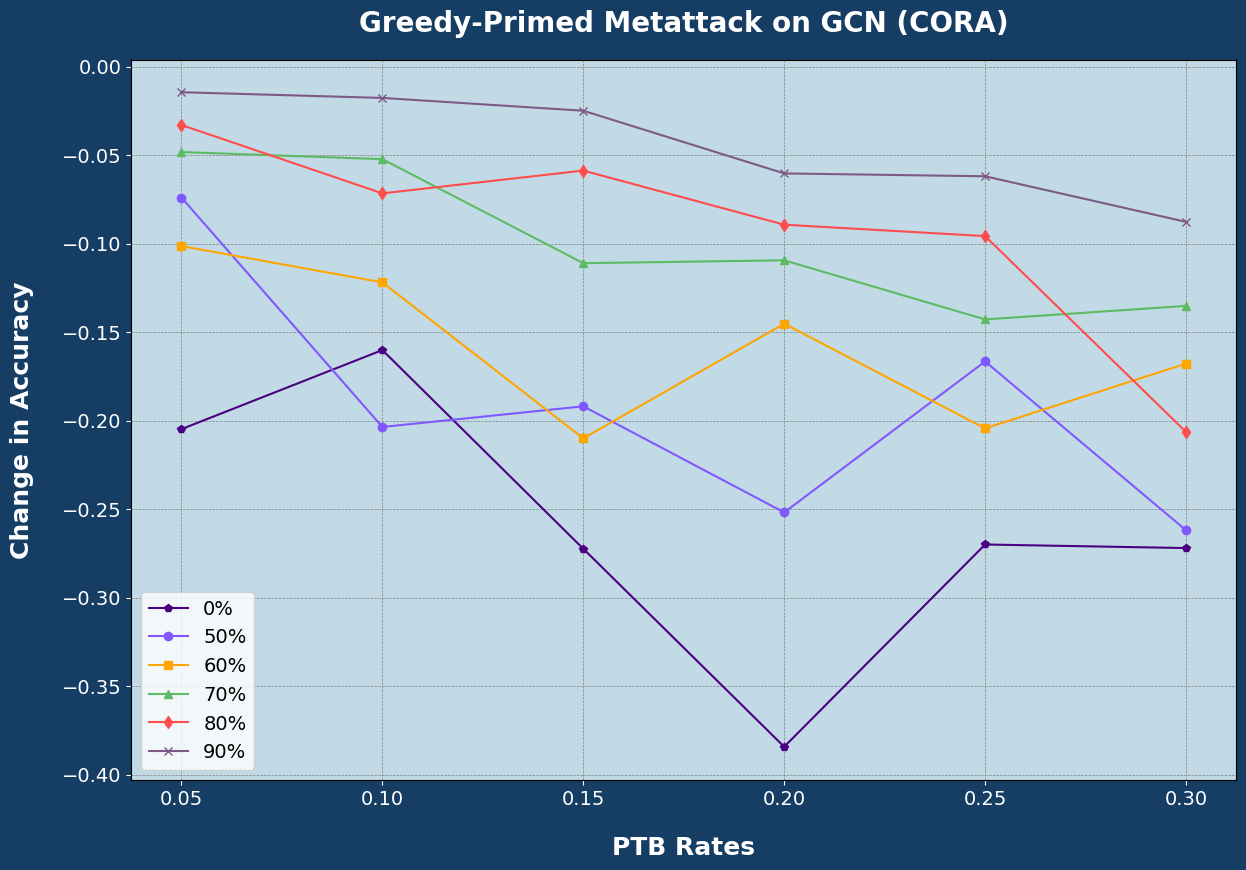

In [119]:
import numpy as np
import matplotlib.pyplot as plt

max_rate = 0.35
ptb_rates = [round((i + 1) * 0.05, 2) for i in range(int(max_rate / 0.05))]

# Define slightly darker pastel colors for the lines
colors = ['#7F58FF', '#FFA500', '#5DBB63', '#FF4C4C', '#7D5A85', '#4B0082']  # Slightly darker shades

# Create a plot with a specified size
plt.figure(figsize=(13, 9), facecolor='#163E64')  # Increased width and height
ax = plt.gca()
ax.set_facecolor('#c2dae6')  # Background color inside the axes

# Plot each architecture's results with the slightly darker pastel colors
plt.plot(ptb_rates, split0_neg, marker='p', linestyle='-', color=colors[5], label='0%')
plt.plot(ptb_rates, split50_neg, marker='o', linestyle='-', color=colors[0], label='50%')
plt.plot(ptb_rates, split60_neg, marker='s', linestyle='-', color=colors[1], label='60%')
plt.plot(ptb_rates, split70_neg, marker='^', linestyle='-', color=colors[2], label='70%')
plt.plot(ptb_rates, split80_neg, marker='d', linestyle='-', color=colors[3], label='80%')
plt.plot(ptb_rates, split90_neg, marker='x', linestyle='-', color=colors[4], label='90%')

# Add title and labels with white color, bold font, and larger font size
plt.title('Greedy-Primed Metattack on GCN (CORA)', color='white', fontweight='bold', fontsize=20, pad=20)
plt.xlabel('PTB Rates', color='white', fontweight='bold', fontsize=18, labelpad=20)
plt.ylabel('Change in Accuracy', color='white', fontweight='bold', fontsize=18, labelpad=20)

# Customize tick parameters to have white color
ax.tick_params(axis='x', colors='white', labelsize=14)
ax.tick_params(axis='y', colors='white', labelsize=14)

# Add legend with a white background
legend = plt.legend(facecolor='white', fontsize=14)
frame = legend.get_frame()
frame.set_facecolor('white')

# Show grid with light color
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Adjust the subplot parameters to reduce padding around the axes labels and title
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1)

# Save plot to a file with higher resolution
plt.savefig('metattack_greedy_split.png', dpi=600, facecolor='#163E64', pad_inches=0.1)

# Show plot
plt.show()
